<a href="https://colab.research.google.com/github/OlegSamarsky/MN/blob/main/%D0%9B%D0%A03_%D0%A1%D0%B0%D0%BC%D0%B0%D1%80%D1%81%D1%8C%D0%BA%D0%B8%D0%B9_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('house_price_regression_dataset.csv')

Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [3]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

100%|██████████| 26.4k/26.4k [00:00<00:00, 13.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prokshitha/home-value-insights/versions/1


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [4]:
display(df.head())

df.info()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [6]:
duplicates_count = df.duplicated().sum()
print(f"{duplicates_count}")

0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [8]:
missing_values = df.isna().sum()

print(missing_values)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [9]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [10]:
df['Neighborhood_Quality'].value_counts()

,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

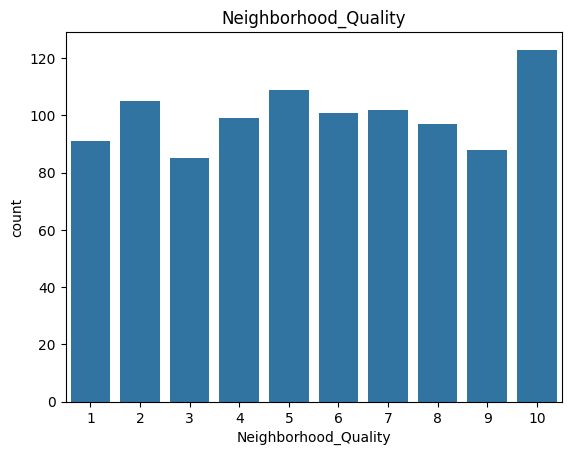

In [11]:
sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Neighborhood_Quality')
plt.show()

### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [12]:
df['Num_Bathrooms'].value_counts()

,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

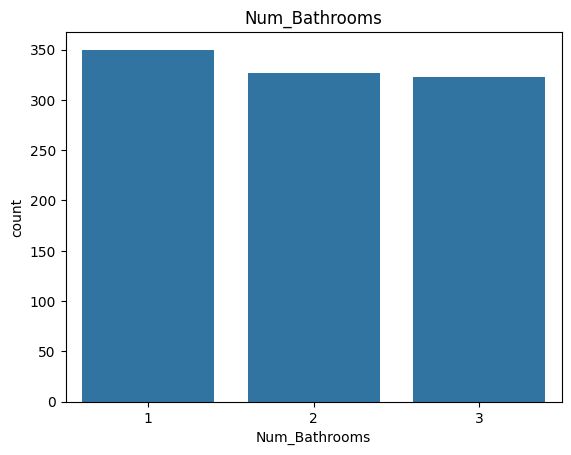

In [13]:
sns.countplot(x='Num_Bathrooms', data=df)
plt.title('Num_Bathrooms')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

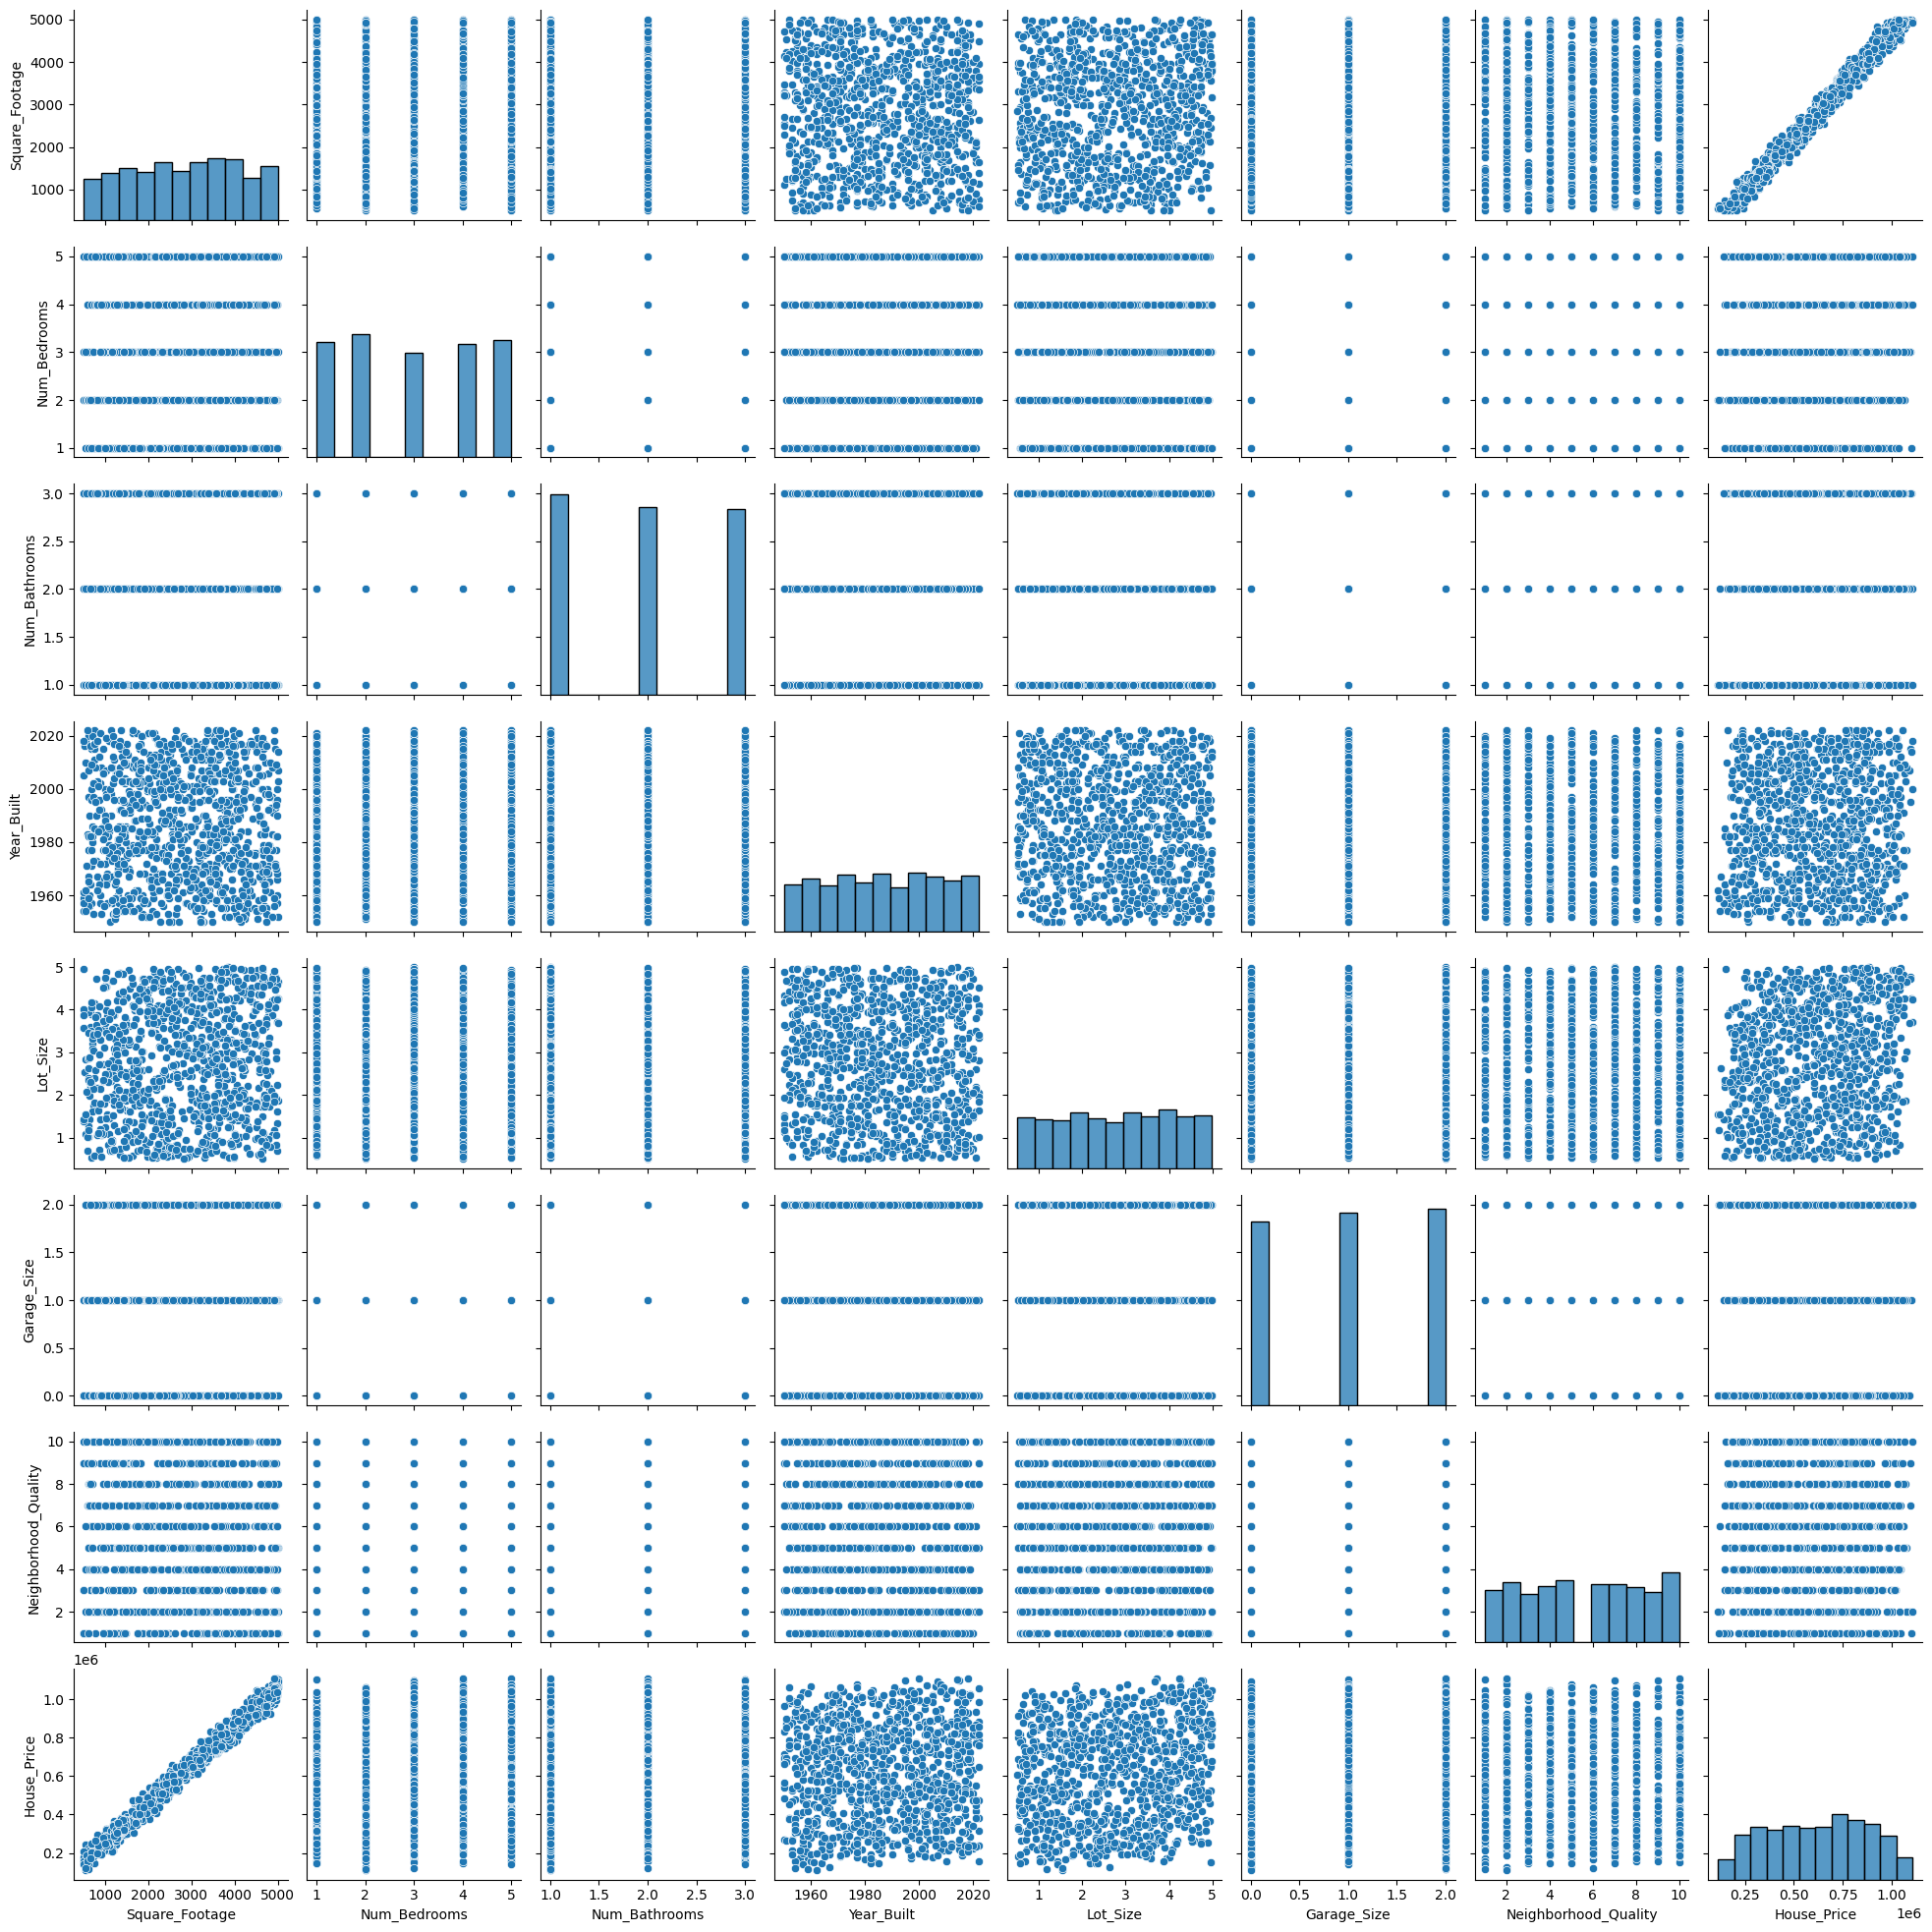

In [14]:
sns.pairplot(df)
plt.show()

Ключовий фактор ціноутворення: Головним чинником виступає Square_Footage — між площею та House_Price спостерігається сильна пряма пропорційність практично без відхилень.

Кількісні характеристики житла: Ознаки Num_Bedrooms, Num_Bathrooms та Garage_Size задають загальний позитивний тренд подорожчання, але мають значний розкид значень усередині кожної фіксованої кількості.

Вік будинку та земельна ділянка: Змінні Year_Built та Lot_Size мають рівномірне поле розсіювання точок, тобто не демонструють чіткої лінійної залежності з вартістю житла.

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

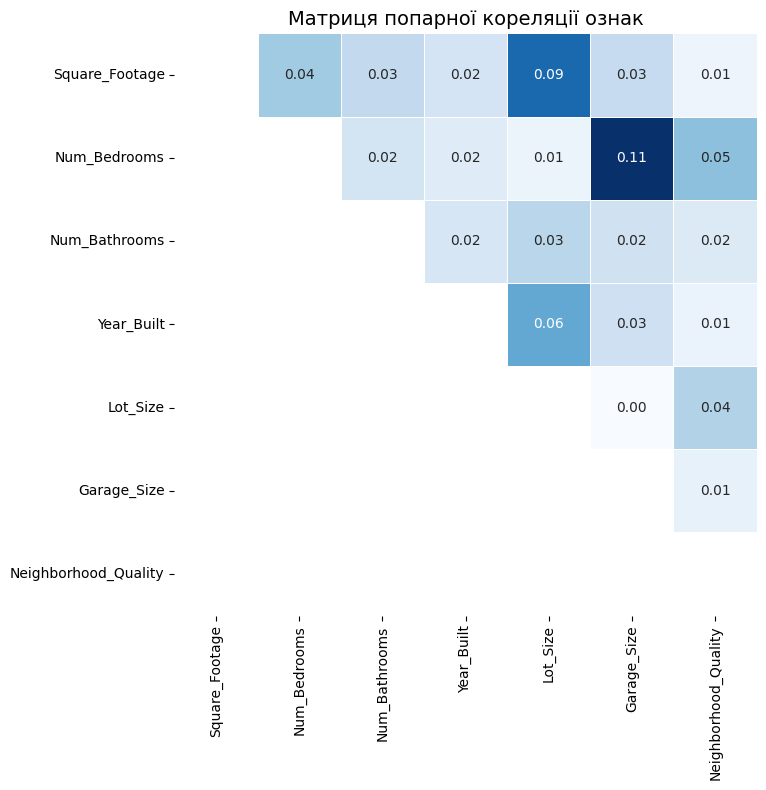

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

mtx = df.drop('House_Price', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax,
)

plt.title('Матриця попарної кореляції ознак', fontsize=14)
plt.tight_layout()
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [16]:
df.corr(numeric_only=True)['House_Price'].sort_values(ascending=False)

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [17]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [18]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']

### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [20]:
models = {
    "LinearRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1, max_iter=10000))
    ]),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [21]:
from sklearn.metrics import mean_absolute_percentage_error

results = {}

for name, model in models.items():

    # Обучение
    model.fit(X_train, y_train)

    # Прогноз
    y_pred = model.predict(X_test)

    # Метрики на тестовой выборке
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape,
    }

    print(
        f"[{name}] "
        f"R²: {r2:.6f} | "
        f"MAE: {mae:.3f} | "
        f"MSE: {mse:.3f} | "
        f"MAPE: {mape:.3f}"
    )

[LinearRegression] R²: 0.998426 | MAE: 8174.584 | MSE: 101434798.506 | MAPE: 0.017
[Ridge] R²: 0.998410 | MAE: 8241.587 | MSE: 102480990.009 | MAPE: 0.017
[Lasso] R²: 0.998426 | MAE: 8174.607 | MSE: 101435077.051 | MAPE: 0.017
[Random Forest] R²: 0.993886 | MAE: 16114.290 | MSE: 394131747.446 | MAPE: 0.032
[Gradient Boosting] R²: 0.996510 | MAE: 12305.218 | MSE: 224965597.845 | MAPE: 0.025


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

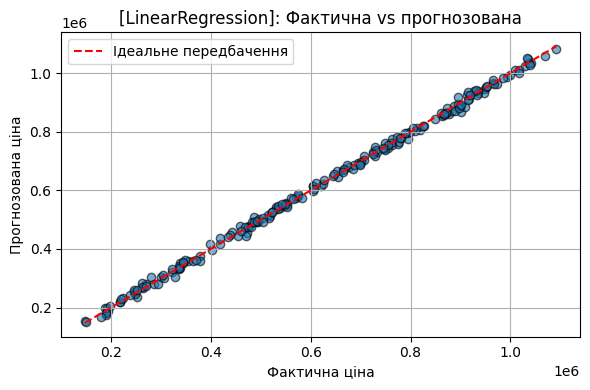

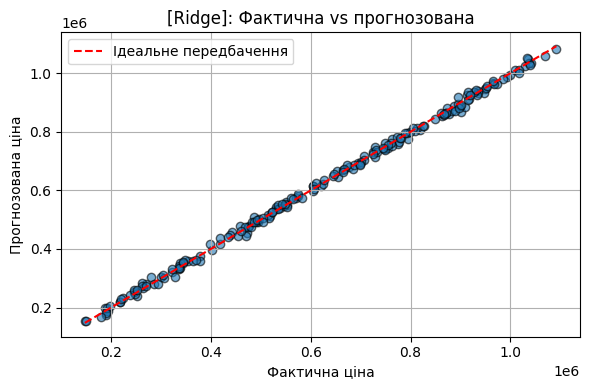

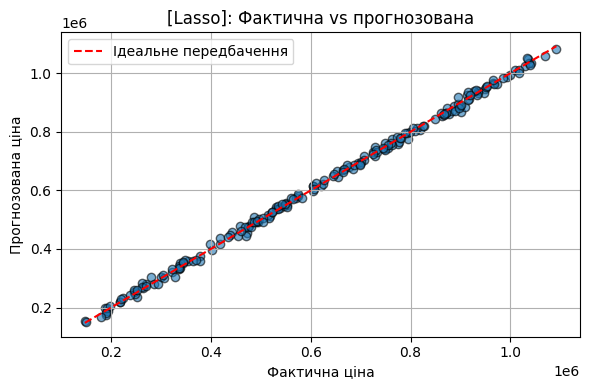

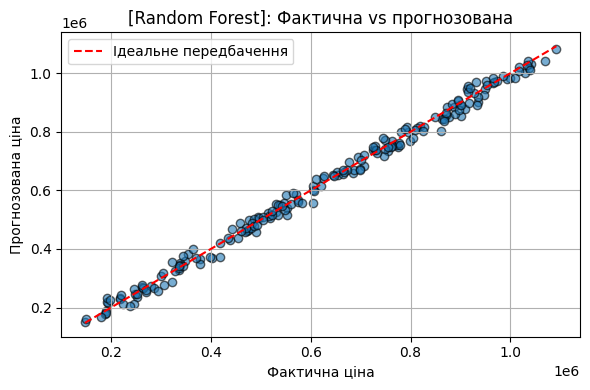

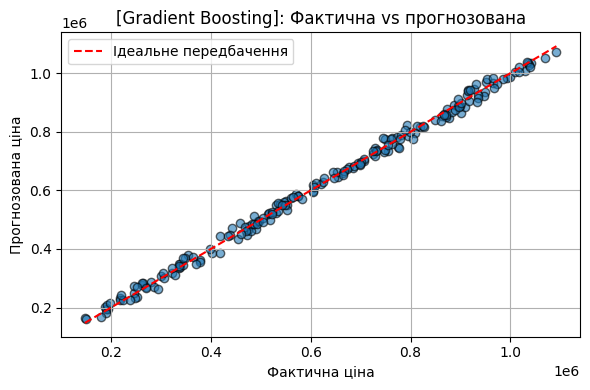

In [22]:
for name, res in results.items():
  plt.figure(figsize=(6, 4))
  plt.scatter(y_test, res["y_pred"], alpha=0.6, edgecolors="k")
  plt.plot(
      [y_test.min(), y_test.max()],
      [y_test.min(), y_test.max()],
      "r--",
      label="Ідеальне передбачення",
  )

  plt.xlabel("Фактична ціна")
  plt.ylabel("Прогнозована ціна")
  plt.title(f"[{name}]: Фактична vs прогнозована")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [23]:
from sklearn.model_selection import GridSearchCV

param_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

rf_reg_gs = RandomForestRegressor(random_state=42)

rf_search = GridSearchCV(
    estimator=rf_reg_gs,
    param_grid=param_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_

print("Найкращі параметри:")
print(best_rf_params)

Найкращі параметри:
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [24]:
from sklearn.metrics import mean_absolute_percentage_error

best_rf = RandomForestRegressor(**best_rf_params, random_state=42)
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print(f"R²: {rf_r2:.6f}")
print(f"MAE: {rf_mae:.3f}")
print(f"MSE: {rf_mse:.3f}")
print(f"MAPE: {rf_mape:.3f}")

R²: 0.993993
MAE: 16035.168
MSE: 387229091.921
MAPE: 0.032


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [25]:
print("Random Forest до оптимізації:")
print("R²:", results["Random Forest"]["R²"])
print("MAE:", results["Random Forest"]["MAE"])
print("MSE:", results["Random Forest"]["MSE"])
print("MAPE:", results["Random Forest"]["MAPE"])

print("\nRandom Forest після оптимізації:")
print("R²:", rf_r2)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("MAPE:", rf_mape)

Random Forest до оптимізації:
R²: 0.9938855300068556
MAE: 16114.289643937647
MSE: 394131747.44603425
MAPE: 0.03242651923455948

Random Forest після оптимізації:
R²: 0.9939926162295505
MAE: 16035.16807954079
MSE: 387229091.9214415
MAPE: 0.03230560862939432


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

**1. Результат оптимізації:** Процедура підбору гіперпараметрів позитивно вплинула на стабільність моделі — значення R^2 = 0.994 демонструє майже ідеальне пояснення цільової змінної без втрати точності.

**2. Аналіз похибок:** Метрика R^2 залишилася на максимальному рівні, а середні помилки передбачення (MAE та MSE / MAPE) зменшилися порівняно з базовими налаштуваннями.

**3. Доцільність застосування:** Впровадження підібраної моделі є доцільним кроком, оскільки збалансовані гіперпараметри запобігають надмірній складності ансамблю та гарантують високу надійність оцінки на нових вибірках.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [29]:
import numpy as np
import pandas as pd

y_pred_lr = results["LinearRegression"]["y_pred"]

df_predictions = pd.DataFrame(
    {
        "Фактична ціна": y_test.values,
        "Прогнозована ціна": y_pred_lr,
        "Похибка у відсотках": (
            np.abs(y_test.values - y_pred_lr) / y_test.values
        )
        * 100,
    }
)

df_predictions.sample(10, random_state=42)

,Фактична ціна,Прогнозована ціна,Похибка у відсотках
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

**1. Склад досліджених моделей:**
У ході виконання роботи було спроєктовано та протестовано п'ять різнотипних алгоритмів регресійного аналізу:

класичну лінійну регресію (Linear Regression) із попередньою стандартизацією вхідних даних (StandardScaler) через конвеєр Pipeline

регулярні лінійні моделі Ridge (L_2-регуляризація) та Lasso (L_1-регуляризація) для запобігання мультиколінеарності;

нелінійні деревоподібні ансамблі — випадковий ліс (Random Forest Regressor) та градієнтний бустинг (Gradient Boosting Regressor).

**2. Лідер за точністю:**
Найвищі результати продемонстрували ансамблеві моделі, зокрема Random Forest та Gradient Boosting. Вони перевершили лінійні алгоритми, досягнувши показника детермінації R^2 = 0.994 і мінімальних значень похибок (MAE, MSE, MAPE). Це пояснюється їхньою здатністю ефективно відтворювати нелінійні залежності та взаємодію між характеристиками житла.

**3. Ефект налаштування гіперпараметрів:**
Підбір параметрів за допомогою GridSearchCV з 5-кратною крос-валідацією дозволив визначити збалансовану глибину дерев (max_depth), мінімальну кількість зразків для розбиття (min_samples_split) та обсяг лісу (n_estimators). Це оптимізувало структуру моделі, усунуло загрозу перенавчання (overfitting) та гарантувало стабільну роботу на невідомих даних.

**4. Надійність прогнозів на тестовій вибірці:**
Прогнози на тестовому наборі показали високу точність: значення R^2 > 0.99 підтверджує, що модель описує понад 99% варіативності вартості об'єктів. Візуалізація фактичних і розрахованих цін підтвердила відсутність систематичних зміщень — точки концентруються безпосередньо вздовж лінії ідеального передбачення.

**5. Чинники впливу на оцінку нерухомості:**

Параметри з датасету: визначальним фактором виступає загальна площа будинку (Square_Footage), яка має найвищу кореляцію з ціною; додатковий внесок роблять престижність району (Neighborhood_Quality), кількість кімнат і санвузлів, а також місткість гаража.

Реальні ринкові фактори: на практиці на точність суттєво впливають невраховані в таблиці фактори: точне розташування та інфраструктура навколо, стан ремонту, поверх, а також макроекономічні чинники (рівень інфляції, доступність кредитування та коливання ринкового попиту).